Code to generate and analyze the Liouville spectrum of the 3 level atom case

In [79]:
from qutip import *
import numpy as np
import time
import matplotlib.pyplot as plt

In [5]:
plt.rcParams.update({
    # LaTeX rendering and font configuration
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],  # mathpazo corresponds to Palatino font
    "font.size": 18,  # Base font size
    
    # Font sizes for specific elements
    "axes.titlesize": 22,        # Axis title
    "axes.labelsize": 20,         # Axis labels
    "xtick.labelsize": 18,        # X-ticks
    "ytick.labelsize": 18,        # Y-ticks
    "legend.fontsize": 18,        # Legend
    "figure.titlesize": 24,       # Figure title
    
    # LaTeX preamble packages
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        \usepackage{lmodern}
        \usepackage{mathpazo}
    """
})

In [59]:
# Parameters
g, κ = 0.1, 1.0
Δ1, Δ2 = 0,0#2*np.pi*g, 2*np.pi*g
η = 0.35*g 

N = 1  # Number of atoms 


Omega = 2*η*g/κ    # Rabi drive strength
varphi = 0#np.pi/2   # Phase 
gamma = 4*g*g/(N*κ)     # Dissipation rate
Delta_1 = Δ1    # Detuning of state 1 from 0
Delta_2 = Δ2   # Detuning of state 2 from 0



# Single-atom operators
sigma_01 = qt.projection(3, 0, 1)  # |0⟩⟨1|
sigma_02 = qt.projection(3, 0, 2)  # |0⟩⟨2|
sigma_10 = sigma_01.dag()
sigma_20 = sigma_02.dag()
proj_1 = qt.projection(3, 1, 1)    # |1⟩⟨1|
proj_2 = qt.projection(3, 2, 2)    # |2⟩⟨2|
id3 = qt.qeye(3)                   # Identity for a single atom

# Initialize composite operators for N atoms
H_detuning = 0
H_drive = 0
c_ops = []

for i in range(N):
    # Detuning terms for atom i
    H_detuning_i = (
        Delta_1 * qt.tensor([id3]*i + [proj_1] + [id3]*(N-i-1)) +
        Delta_2 * qt.tensor([id3]*i + [proj_2] + [id3]*(N-i-1)))
    H_detuning += H_detuning_i

    # Drive terms for atom i
    drive_i = Omega * (
        qt.tensor([id3]*i + [sigma_01] + [id3]*(N-i-1)) +
        qt.tensor([id3]*i + [sigma_10] + [id3]*(N-i-1)) +
        np.exp(-1j * varphi) * qt.tensor([id3]*i + [sigma_02] + [id3]*(N-i-1)) +
        np.exp(1j * varphi) * qt.tensor([id3]*i + [sigma_20] + [id3]*(N-i-1)))
    H_drive += drive_i

    # Dissipator for atom i
    L_i = np.sqrt(gamma) * (
        qt.tensor([id3]*i + [sigma_01] + [id3]*(N-i-1)) +
        np.exp(-1j * varphi) * qt.tensor([id3]*i + [sigma_02] + [id3]*(N-i-1)))
    c_ops.append(L_i)

# Full Hamiltonian and Liouvillian
H = H_detuning + H_drive
liouv = qt.liouvillian(H, c_ops)

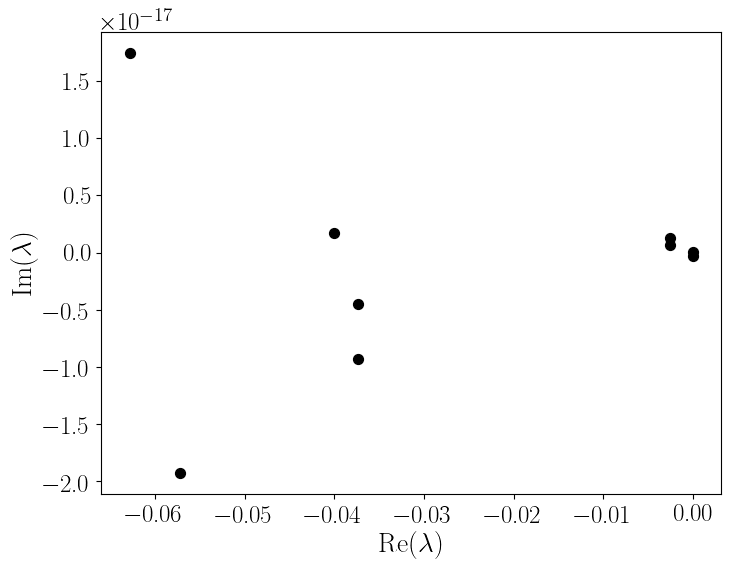

In [60]:
eigenvalues = liouv.eigenenergies(sort='high')#, tol=1e-10)
sorted_indices = np.argsort(-np.real(eigenvalues))
eigenvalues = eigenvalues[sorted_indices]

# Plot eigenvalues
real_parts = np.real(eigenvalues)
imag_parts = np.imag(eigenvalues)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(real_parts, imag_parts, color='black', label='Eigenvalues', s=50)

plt.xlabel(r'Re($\lambda$)')
plt.ylabel(r'Im($\lambda$)')
# plt.xticks([0,-1e-5],[0, 1])
# plt.xlim(-1.2e-5,5e-8)
# plt.ylim(-1e-9, 1e-5)
# plt.axhline(Delta_1)
# plt.axhline(2*Delta_1)
# plt.axhline(-Delta_1)
# plt.axhline(-2*Delta_1)
plt.show()

# np.savetxt('Liouv+Det_real.txt', real_parts)
# np.savetxt('Liouv+Det_imag.txt', imag_parts)

In [68]:
eigs, vecs = liouv.eigenstates()

In [81]:
Qobj(vecs[0].full().reshape((3,3)))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.34186614e-01+0.00000000e+00j -3.40177141e-16+3.27600871e-01j
  -1.57951862e-16+3.27600871e-01j]
 [ 3.53798636e-16-3.27600871e-01j -2.67093307e-01+1.20557452e-17j
  -2.67093307e-01-1.57058442e-17j]
 [ 3.53798636e-16-3.27600871e-01j -2.67093307e-01+1.20557452e-17j
  -2.67093307e-01-1.57058442e-17j]]

In [ ]:
Qobj(vecs[1].full().reshape((3,3)))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 4.63297594e-01+0.00000000e+00j  3.12163687e-16+3.77726977e-01j
   4.70206834e-16+3.77726977e-01j]
 [-3.00349828e-16-3.77726977e-01j -2.31648797e-01+8.16038119e-18j
  -2.31648797e-01-1.59171176e-17j]
 [-3.00349828e-16-3.77726977e-01j -2.31648797e-01+8.16038119e-18j
  -2.31648797e-01-1.59171176e-17j]]

In [84]:
Qobj(vecs[2].full().reshape((3,3)))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-5.38002182e-17  5.00000000e-01  5.00000000e-01]
 [ 5.00000000e-01 -2.33480513e-15  1.45811429e-15]
 [ 5.00000000e-01 -1.38427824e-15  2.13517488e-15]]

In [83]:
eigs

array([-6.28284271e-02+1.74546738e-17j, -5.71715729e-02-1.93339435e-17j,
       -4.00000000e-02+1.68973327e-18j, -3.73781472e-02-9.35898888e-18j,
       -3.73781472e-02-4.49632395e-18j, -2.62185280e-03+6.66227028e-19j,
       -2.62185280e-03+1.28070855e-18j,  5.73904849e-19+1.90474571e-20j,
        2.62686093e-18-3.43344772e-19j])

In [45]:
eigenvalues = liouv.eigenenergies(sparse=True, sort='high',eigvals=16, tol=1e-3)
sorted_indices = np.argsort(-np.real(eigenvalues))
eigenvalues = eigenvalues[sorted_indices]

# Plot eigenvalues
real_parts = np.real(eigenvalues)
imag_parts = np.imag(eigenvalues)
#np.savetxt('Liouv+Det_real.txt', real_parts)
#np.savetxt('Liouv+Det_imag.txt', imag_parts)

np.savetxt('Liouv-Det_real.txt', real_parts)
np.savetxt('Liouv-Det_imag.txt', imag_parts)



Plotting both eDFS and DFS on single plot

ValueError: x and y must be the same size

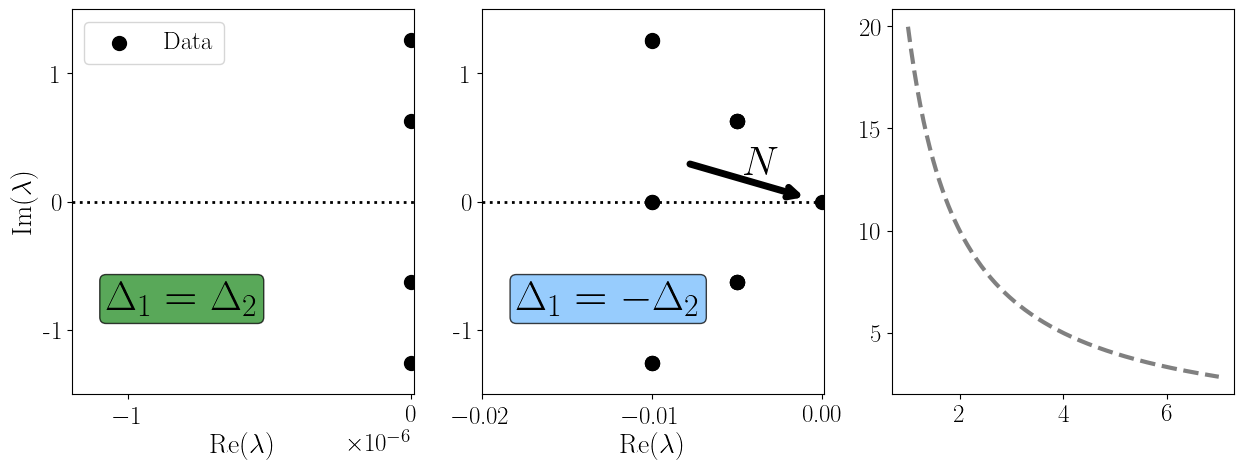

In [ ]:
# — your data placeholders — 
# (we need  real_parts1, imag_parts1, real_parts2, imag_parts2, Ns, gaps, x_fit, fit defined)

real1 = np.loadtxt('Liouv+Det_real.txt')
imag1 = np.loadtxt('Liouv+Det_imag.txt')
parts1 = (real1, imag1)

real2 = np.loadtxt('Liouv-Det_real.txt')
imag2 = np.loadtxt('Liouv-Det_imag.txt')
parts2 = (real2, imag2)

gaps = np.loadtxt('gaps.txt') 


fig = plt.figure(figsize=(15, 5))

# Left panel
ax0 = fig.add_subplot(1, 3, 1)
ax0.scatter(parts1[0], parts1[1], color='black', label='Data', s=100)
ax0.set_xlabel(r'Re($\lambda$)')
ax0.set_ylabel(r'Im($\lambda$)')
ax0.set_xticks([0, -1e-6])
ax0.set_yticks([-1,0,1],[-1,0,1])
ax0.set_xlim(-1.2e-6, 1e-8)
ax0.set_ylim(-1.5,1.5)
ax0.axhline(0, color="black", lw=2, linestyle=":")
ax0.text(
    0.1, 0.2, r"$\mathrm{\Delta_1}=\mathrm{\Delta_2}$",
    transform=ax0.transAxes,
    fontsize=30,
    color="black",
    va="bottom",
    ha="left",
    bbox=dict(facecolor="forestgreen", edgecolor="black", boxstyle="round,pad=0.15", alpha=0.75)
)

ax0.legend(loc="upper left")

# Middle panel (shares y-axis with left)
ax1 = fig.add_subplot(1, 3, 2, sharey=ax0)
ax1.scatter(parts2[0], parts2[1], color='black', label='Data', s=100)
ax1.set_xlabel(r'Re($\lambda$)')
# no need to set ylabel again since shared
ax1.axhline(0, color="black", lw=2, linestyle=":")
ax1.set_xticks([0,  -1e-2, -2e-2])
ax1.set_yticks([-1,0,1],[-1,0,1])
ax1.set_xlim(-2e-2, 1e-4)
ax1.set_ylim(-1.5,1.5)
ax1.text(
    0.1, 0.2, r"$\mathrm{\Delta_1}=-\mathrm{\Delta_2}$",
    transform=ax1.transAxes,
    fontsize=30,
    color="black",
    va="bottom",
    ha="left",
    bbox=dict(facecolor="xkcd:sky blue", edgecolor="black", boxstyle="round,pad=0.15", alpha=0.75)
)
ax1.annotate(
    '', 
    xy=(0.95, 0.51),       # arrow head (in axes fraction)
    xytext=(0.6, 0.6),   # arrow tail
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='->', lw=5)
)
ax1.text(
    0.81, 0.55, r'$N$',
    transform=ax1.transAxes,
    va='bottom', ha='center',
    fontsize=30
)

# Right panel: finite‐size scaling
ax2 = fig.add_subplot(1, 3, 3)
ax2.plot(x_fit, fit*1e3, linestyle='--', color='grey', label=r'$1/N$ fit', lw=3)
ax2.scatter(Ns, gaps*1e3, color='black', s=100)
ax2.set_xlabel(r'System size $N$')
ax2.set_ylabel(r'$\mathcal{L}\;\mathrm{-gap\,} (\times10^{-3})$')
ax2.legend()
ax2.set_yscale('log')
ax2.set_yticks([50, 10, 1], [50, 10,1])
ax2.set_xticks([1,3,5,7])
# labels already match ticks
ax2.tick_params(axis='both', which='major')

fig.tight_layout()
plt.show()

# plt.savefig("fig4.svg", bbox_inches="tight")

Scaling of Liouvillian gap